# NutriVision — Level 2: Nutrition Estimation Pipeline

**EECE 5639: Computer Vision, Spring 2026** | Radhika Khurana

Level 2 extends the Level 1 classifier with:
- Improved training (label smoothing + cosine LR annealing)
- Per-image nutrition lookup via a USDA FoodData Central-derived database
- End-to-end pipeline: image → classification → nutrition facts
- Multi-food handling via image grid splitting
- Nutritional analysis across food categories

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import Food101
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import json, time, copy
from tqdm import tqdm

from src.nutrition import get_nutrition, format_nutrition_label, get_macro_breakdown, compare_foods

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: mps


## 1. Load Level 1 Model

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

DATA_DIR = './data'
test_dataset = Food101(root=DATA_DIR, split='test', transform=test_transform, download=True)
class_names  = test_dataset.classes
num_classes  = len(class_names)
print(f'{num_classes} classes, {len(test_dataset)} test images')

101 classes, 25250 test images


In [3]:
def load_resnet50(weights_path, num_classes=101):
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    state = torch.load(weights_path, map_location=device, weights_only=False)
    model.load_state_dict(state)
    model = model.to(device)
    model.eval()
    return model

resnet_model = load_resnet50('../models/resnet50_food101_best.pth')
print('ResNet-50 loaded.')

ResNet-50 loaded.


## 2. Advanced Training: Label Smoothing + Cosine Annealing

Two improvements over the Level 1 training setup:
- **Label smoothing (ε=0.1):** softens hard targets to prevent overconfident predictions
- **Cosine annealing LR:** decays the learning rate smoothly rather than step-wise

The training function below is ready to run — loading pre-trained weights for the pipeline demo since retraining takes ~2 hours on Colab T4.

In [4]:
def train_improved(model_name='resnet50', phase1_epochs=5, phase2_epochs=15,
                   head_lr=1e-3, finetune_lr_head=1e-4, finetune_lr_backbone=1e-5,
                   label_smoothing=0.1, patience=5, batch_size=32, num_workers=2):

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    full = Food101(root=DATA_DIR, split='train', transform=train_transform, download=True)
    n_train = int(0.9 * len(full))
    train_ds, val_ds = random_split(full, [n_train, len(full) - n_train],
                                    generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # label smoothing replaces hard 1/0 targets with (1-eps) / eps/K
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model   = models.resnet50(weights=weights)
        model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
        head_params = list(model.fc.parameters())
    else:
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
        model   = models.mobilenet_v3_large(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        head_params = list(model.classifier.parameters())

    for p in model.parameters(): p.requires_grad = False
    for p in head_params:        p.requires_grad = True
    model = model.to(device)

    history = {'train_loss': [], 'val_acc': [], 'phase': []}
    best_val_acc, best_weights = 0.0, None

    # phase 1 — head only
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=head_lr)
    for epoch in range(1, phase1_epochs + 1):
        model.train()
        for imgs, lbls in tqdm(train_loader, desc=f'P1 E{epoch}', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
            history['train_loss'].append(loss.item())
            history['phase'].append(1)

        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                _, pred = model(imgs.to(device)).max(1)
                correct += pred.eq(lbls.to(device)).sum().item()
                total   += lbls.size(0)
        val_acc = 100. * correct / total
        history['val_acc'].append(val_acc)
        print(f'  P1 [{epoch}/{phase1_epochs}] val {val_acc:.2f}%')
        if val_acc > best_val_acc:
            best_val_acc, best_weights = val_acc, copy.deepcopy(model.state_dict())

    # phase 2 — full fine-tune with cosine annealing
    for p in model.parameters(): p.requires_grad = True
    if model_name == 'resnet50':
        bp = [p for n, p in model.named_parameters() if 'fc' not in n]
        hp = list(model.fc.parameters())
    else:
        bp = [p for n, p in model.named_parameters() if 'classifier' not in n]
        hp = list(model.classifier.parameters())

    optimizer = optim.Adam([{'params': bp, 'lr': finetune_lr_backbone},
                             {'params': hp, 'lr': finetune_lr_head}])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase2_epochs)
    no_improve = 0

    for epoch in range(1, phase2_epochs + 1):
        g = epoch + phase1_epochs
        model.train()
        for imgs, lbls in tqdm(train_loader, desc=f'P2 E{g}', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
            history['train_loss'].append(loss.item())
            history['phase'].append(2)
        scheduler.step()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                _, pred = model(imgs.to(device)).max(1)
                correct += pred.eq(lbls.to(device)).sum().item()
                total   += lbls.size(0)
        val_acc = 100. * correct / total
        history['val_acc'].append(val_acc)
        print(f'  P2 [{g}/{phase1_epochs+phase2_epochs}] val {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc, best_weights, no_improve = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f'Early stop at epoch {g}')
            break

    model.load_state_dict(best_weights)
    print(f'Best val acc: {best_val_acc:.2f}%')
    return model, history

# Uncomment to retrain with improved setup (~2 hrs on Colab T4):
# improved_model, history = train_improved('resnet50')
# torch.save(improved_model.state_dict(), '../models/resnet50_improved.pth')
print('train_improved() ready. Using Level 1 weights for demo.')

train_improved() ready. Using Level 1 weights for demo.


## 3. Nutrition Database

In [5]:
# Spot-check a few foods
for food in ['pizza', 'grilled_salmon', 'caesar_salad', 'cheesecake', 'miso_soup']:
    print(format_nutrition_label(food))
    print()

  Pizza  (serving: 200g)
  Calories:  532 kcal
  Protein:   22.0 g
  Carbs:     66.0 g
  Fat:       20.0 g
  Fiber:     4.0 g

  Grilled Salmon  (serving: 200g)
  Calories:  374 kcal
  Protein:   50.0 g
  Carbs:     0.0 g
  Fat:       18.0 g
  Fiber:     0.0 g

  Caesar Salad  (serving: 200g)
  Calories:  210 kcal
  Protein:   8.0 g
  Carbs:     14.0 g
  Fat:       16.0 g
  Fiber:     2.0 g

  Cheesecake  (serving: 125g)
  Calories:  401 kcal
  Protein:   6.2 g
  Carbs:     32.5 g
  Fat:       27.5 g
  Fiber:     0.4 g

  Miso Soup  (serving: 250g)
  Calories:  100 kcal
  Protein:   7.5 g
  Carbs:     10.0 g
  Fat:       2.5 g
  Fiber:     1.2 g



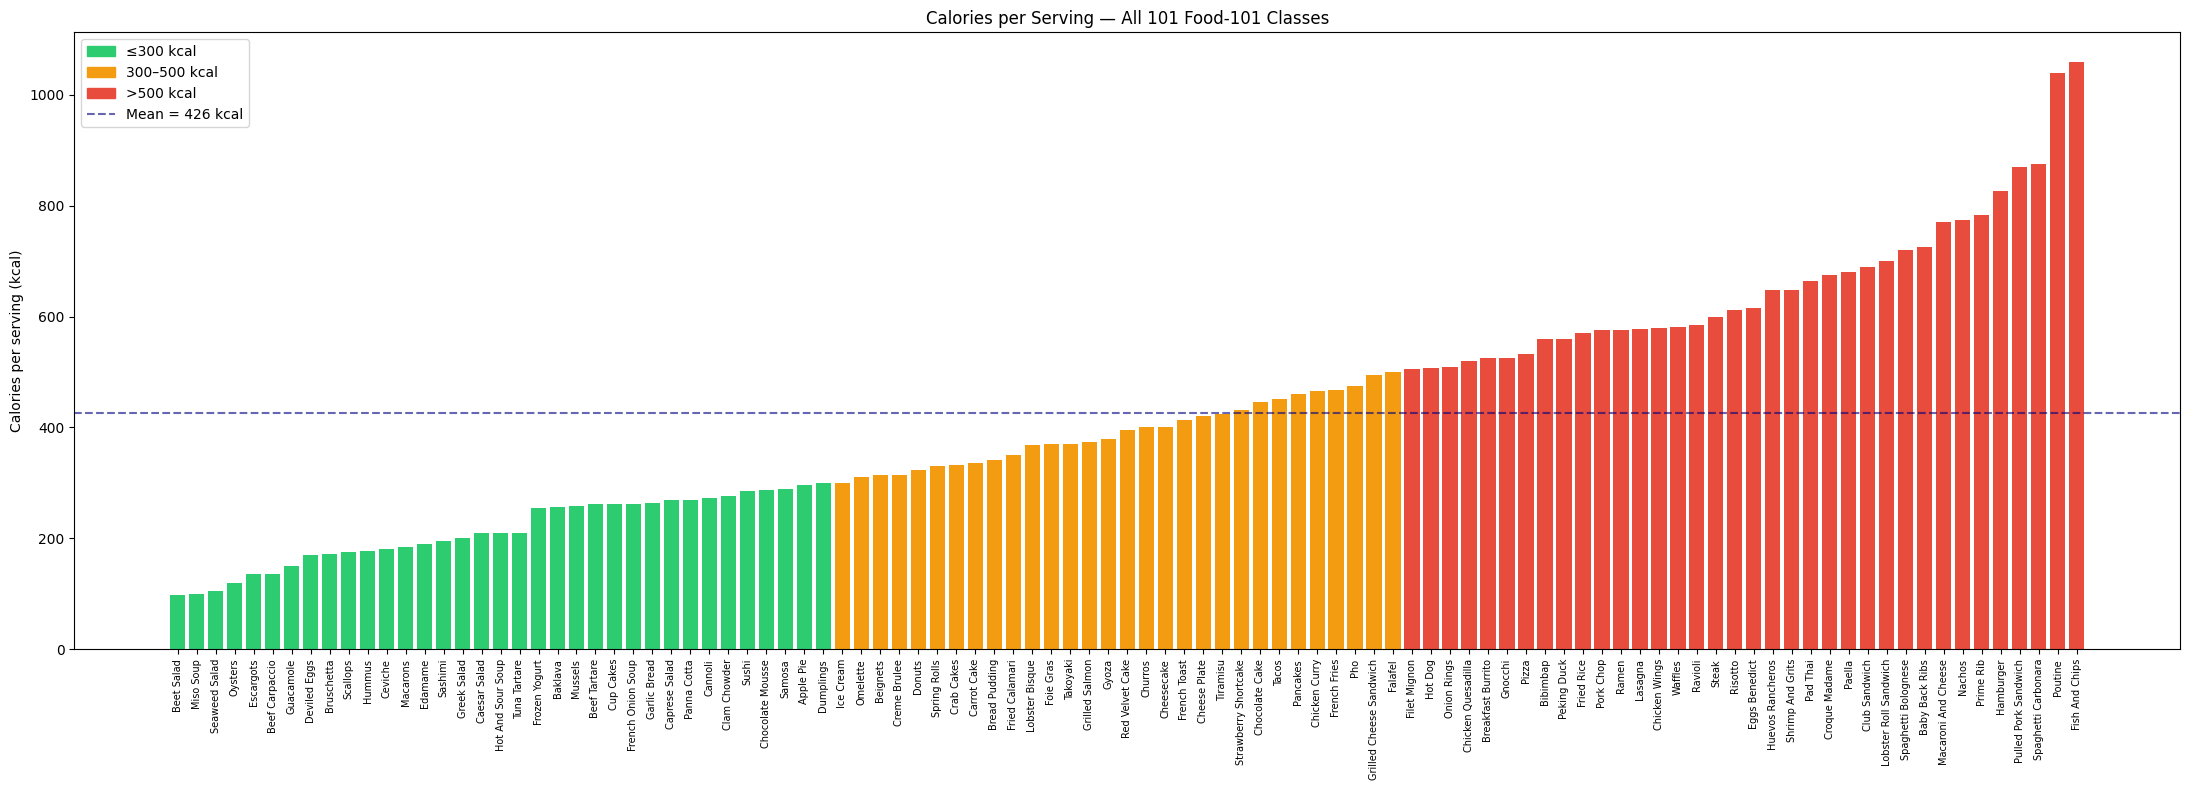

Mean: 426 kcal | Min: 98 | Max: 1060


In [6]:
# Overview: calorie distribution across all 101 classes
from src.nutrition import NUTRITION_PER_100G, SERVING_SIZE_G

all_foods  = list(NUTRITION_PER_100G.keys())
all_cals   = []
all_labels = []
for food in all_foods:
    info = get_nutrition(food)
    all_cals.append(info['per_serving']['calories'])
    all_labels.append(info['food'])

sorted_pairs = sorted(zip(all_cals, all_labels))
cals_sorted, labels_sorted = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(22, 8))
colors = ['#e74c3c' if c > 500 else '#f39c12' if c > 300 else '#2ecc71' for c in cals_sorted]
ax.bar(range(len(cals_sorted)), cals_sorted, color=colors, width=0.8)
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=90, fontsize=7)
ax.set_ylabel('Calories per serving (kcal)')
ax.set_title('Calories per Serving — All 101 Food-101 Classes')
ax.axhline(np.mean(cals_sorted), color='navy', linestyle='--', alpha=0.6, label=f'Mean = {np.mean(cals_sorted):.0f} kcal')
patches = [mpatches.Patch(color='#2ecc71', label='≤300 kcal'),
           mpatches.Patch(color='#f39c12', label='300–500 kcal'),
           mpatches.Patch(color='#e74c3c', label='>500 kcal')]
ax.legend(handles=patches + [ax.get_lines()[0]])
plt.tight_layout()
plt.savefig('../results/figures/calorie_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean: {np.mean(cals_sorted):.0f} kcal | Min: {min(cals_sorted):.0f} | Max: {max(cals_sorted):.0f}')

## 4. End-to-End Pipeline: Image → Classification → Nutrition

In [7]:
def denormalize(tensor):
    t = tensor.clone()
    for i, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[i] = t[i] * s + m
    return torch.clamp(t, 0, 1)

def predict_and_lookup(model, img_tensor, class_names, top_k=5):
    model.eval()
    with torch.no_grad():
        out   = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1).squeeze().cpu().numpy()
    top_idx   = probs.argsort()[-top_k:][::-1]
    top_probs = probs[top_idx]
    top_names = [class_names[i] for i in top_idx]
    prediction = top_names[0]
    nutrition  = get_nutrition(prediction)
    return prediction, top_names, top_probs, nutrition

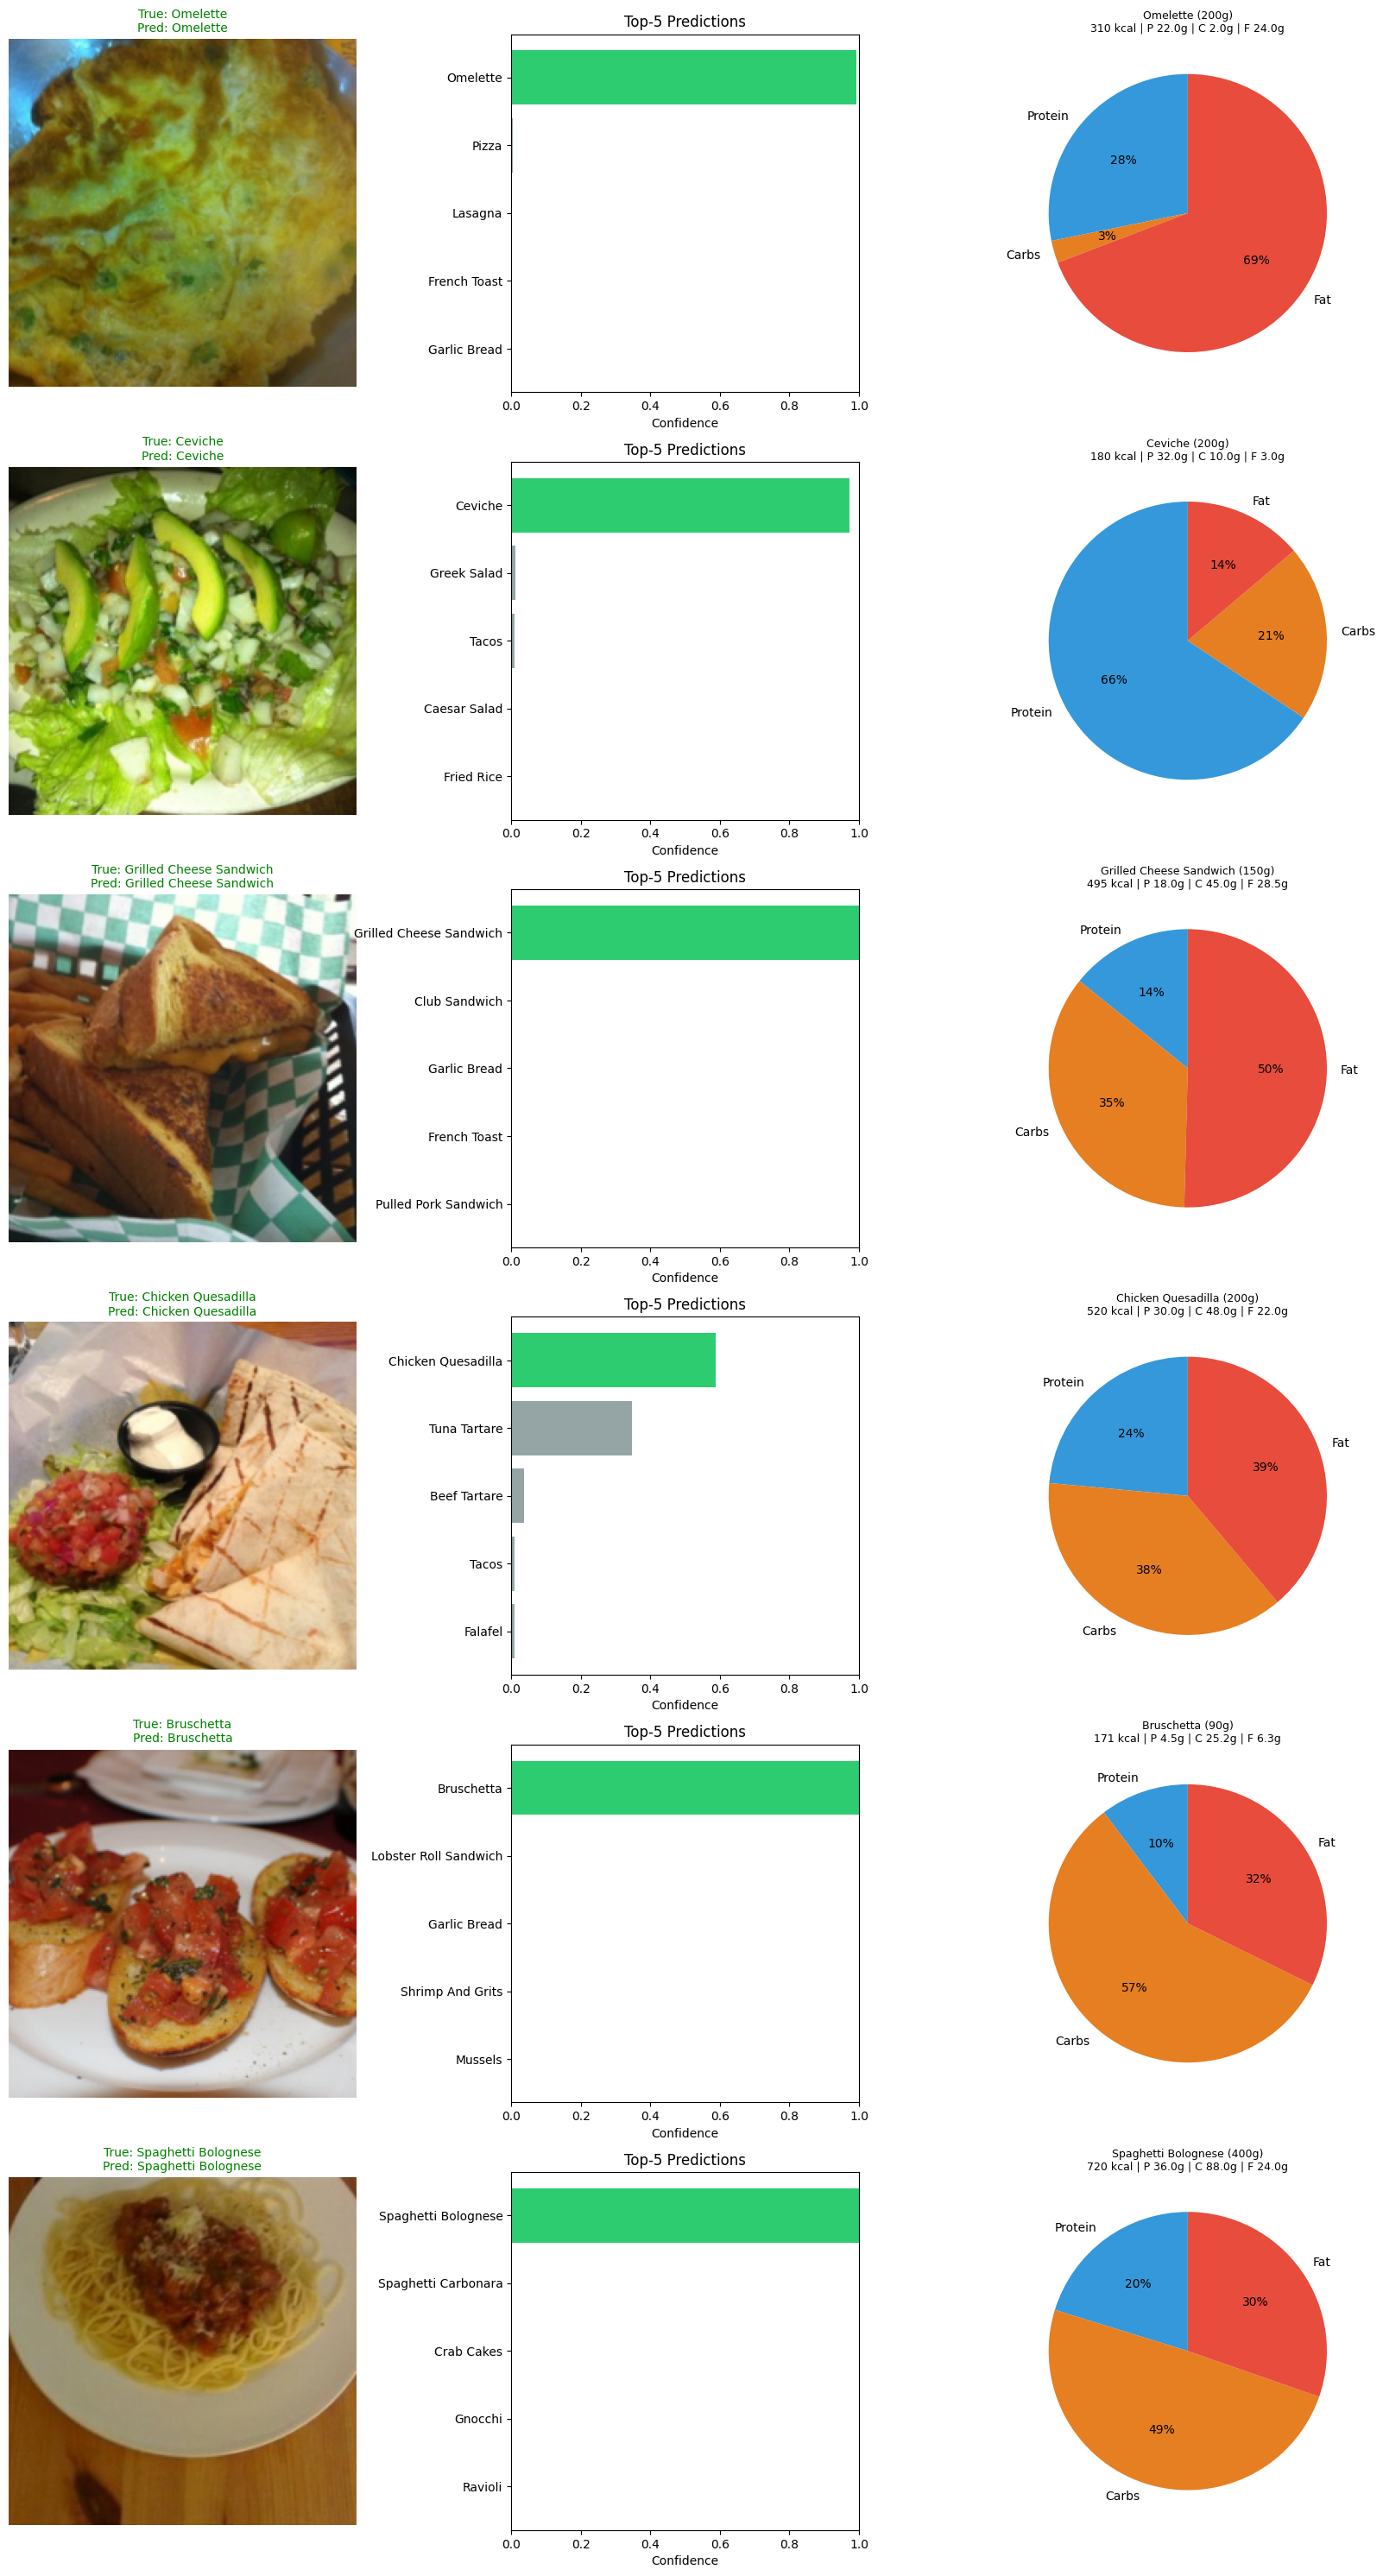

In [8]:
def run_pipeline(model, dataset, class_names, indices):
    fig, axes = plt.subplots(len(indices), 3, figsize=(16, 5 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        pred_name, top5_names, top5_probs, nutrition = predict_and_lookup(
            model, img_tensor, class_names
        )
        img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()
        true_name   = class_names[true_label].replace('_', ' ').title()
        pred_display = pred_name.replace('_', ' ').title()

        # image
        axes[row, 0].imshow(img_display)
        correct = pred_name == class_names[true_label]
        axes[row, 0].set_title(
            f'True: {true_name}\nPred: {pred_display}',
            color='green' if correct else 'red', fontsize=10
        )
        axes[row, 0].axis('off')

        # top-5 bar chart
        colors = ['#2ecc71' if n == class_names[true_label] else '#95a5a6' for n in top5_names]
        axes[row, 1].barh(
            [n.replace('_', ' ').title() for n in top5_names], top5_probs, color=colors
        )
        axes[row, 1].set_xlim(0, 1)
        axes[row, 1].invert_yaxis()
        axes[row, 1].set_xlabel('Confidence')
        axes[row, 1].set_title('Top-5 Predictions')

        # nutrition card
        if nutrition:
            s = nutrition['per_serving']
            macro = get_macro_breakdown(pred_name)
            labels = ['Protein', 'Carbs', 'Fat']
            vals   = [macro['protein_pct'], macro['carbs_pct'], macro['fat_pct']]
            colors_pie = ['#3498db', '#e67e22', '#e74c3c']
            axes[row, 2].pie(vals, labels=labels, colors=colors_pie,
                             autopct='%1.0f%%', startangle=90)
            axes[row, 2].set_title(
                f'{nutrition["food"]} ({nutrition["serving_g"]}g)\n'
                f'{s["calories"]:.0f} kcal | P {s["protein_g"]}g | C {s["carbs_g"]}g | F {s["fat_g"]}g',
                fontsize=9
            )

    plt.tight_layout()
    plt.savefig('../results/figures/pipeline_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

np.random.seed(7)
sample_idx = np.random.choice(len(test_dataset), 6, replace=False)
run_pipeline(resnet_model, test_dataset, class_names, sample_idx)

## 5. Nutritional Analysis

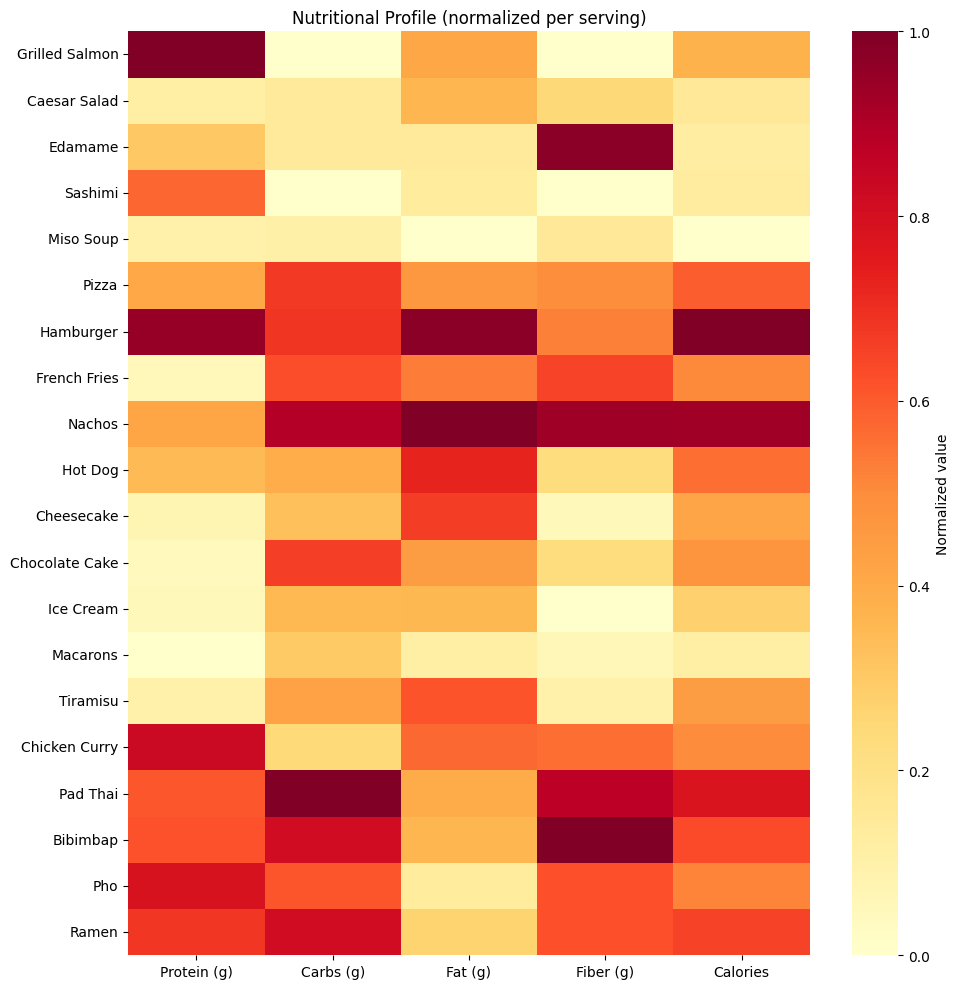

In [9]:
# Macro breakdown heatmap — select a range of foods
selected = [
    'grilled_salmon', 'caesar_salad', 'edamame', 'sashimi', 'miso_soup',
    'pizza', 'hamburger', 'french_fries', 'nachos', 'hot_dog',
    'cheesecake', 'chocolate_cake', 'ice_cream', 'macarons', 'tiramisu',
    'chicken_curry', 'pad_thai', 'bibimbap', 'pho', 'ramen',
]
macro_data = []
for food in selected:
    info = get_nutrition(food)
    s = info['per_serving']
    macro_data.append([s['protein_g'], s['carbs_g'], s['fat_g'], s['fiber_g'], s['calories']])

macro_arr = np.array(macro_data)
labels    = [f.replace('_', ' ').title() for f in selected]
cols      = ['Protein (g)', 'Carbs (g)', 'Fat (g)', 'Fiber (g)', 'Calories']

fig, ax = plt.subplots(figsize=(10, 10))
norm_data = (macro_arr - macro_arr.min(0)) / (macro_arr.max(0) - macro_arr.min(0) + 1e-8)
sns.heatmap(norm_data, xticklabels=cols, yticklabels=labels,
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Normalized value'})
ax.set_title('Nutritional Profile (normalized per serving)')
plt.tight_layout()
plt.savefig('../results/figures/nutrition_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

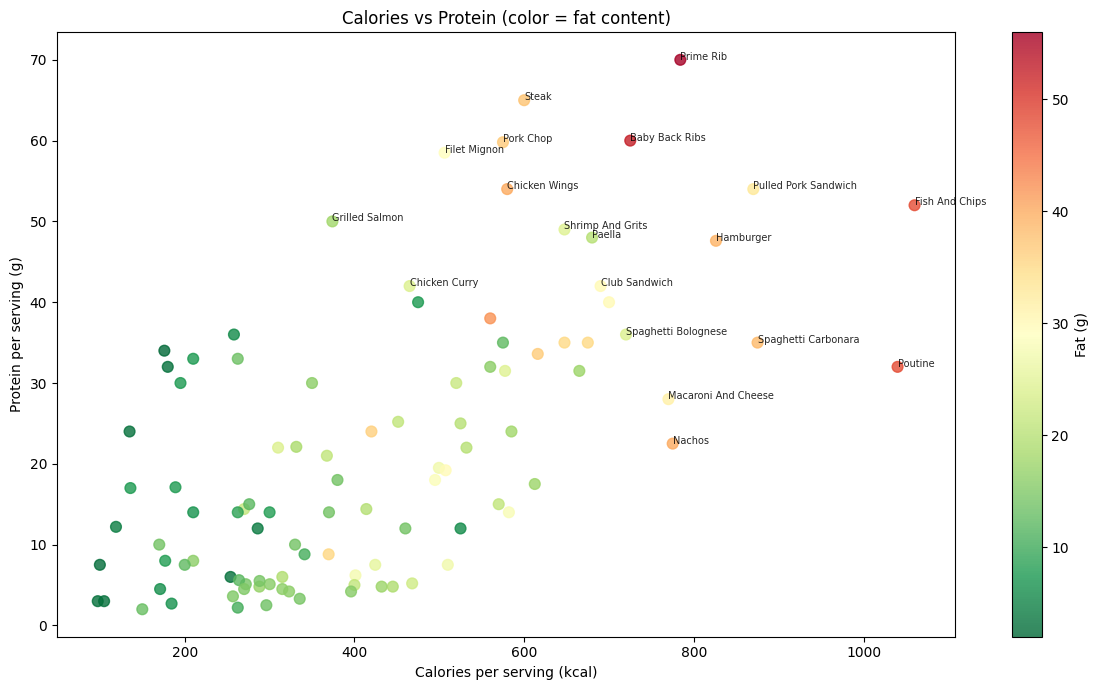

In [10]:
# Scatter: calories vs protein, colored by fat content
foods_plot = list(NUTRITION_PER_100G.keys())
xs, ys, cs, ns = [], [], [], []
for food in foods_plot:
    info = get_nutrition(food)
    s = info['per_serving']
    xs.append(s['calories'])
    ys.append(s['protein_g'])
    cs.append(s['fat_g'])
    ns.append(info['food'])

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(xs, ys, c=cs, cmap='RdYlGn_r', s=60, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Fat (g)')
ax.set_xlabel('Calories per serving (kcal)')
ax.set_ylabel('Protein per serving (g)')
ax.set_title('Calories vs Protein (color = fat content)')
for i, name in enumerate(ns):
    if ys[i] > 40 or xs[i] > 700:
        ax.annotate(name, (xs[i], ys[i]), fontsize=7, alpha=0.85)
plt.tight_layout()
plt.savefig('../results/figures/calories_vs_protein.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Multi-Food Handling

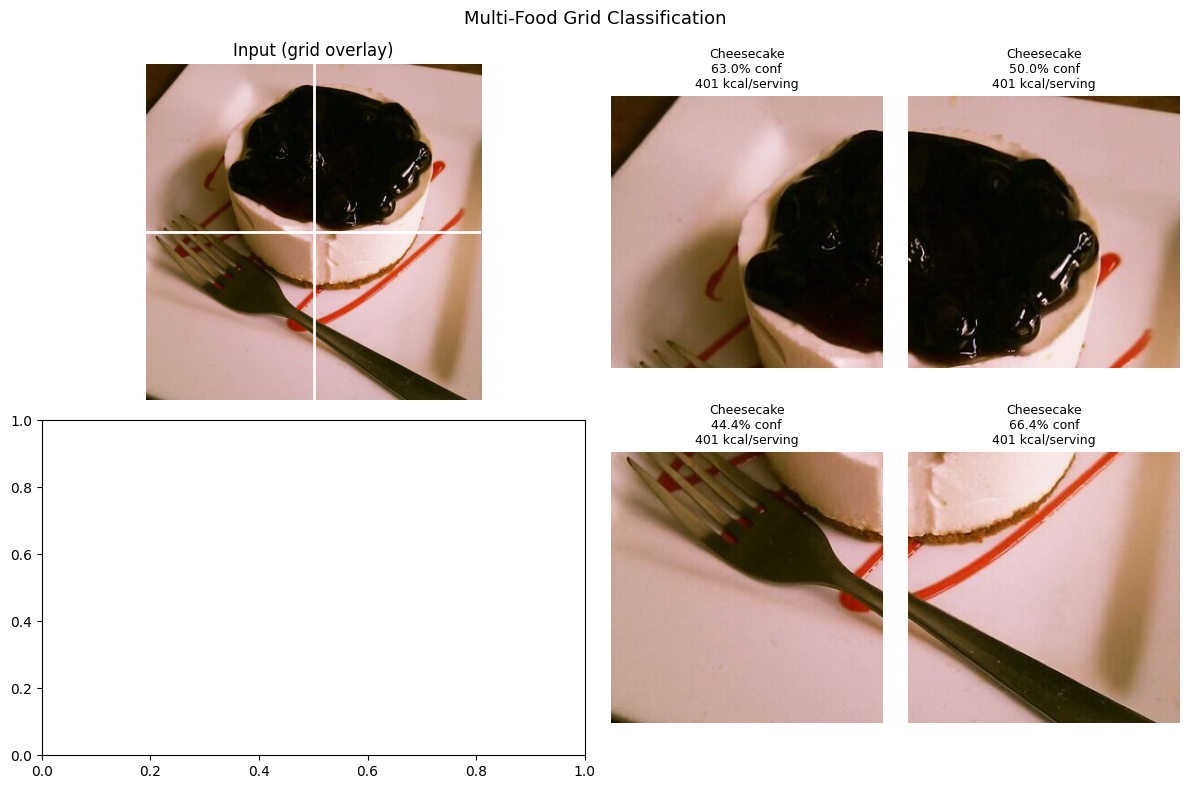

Region (0, 0): Cheesecake (63.0%) — 401 kcal/serving
Region (0, 1): Cheesecake (50.0%) — 401 kcal/serving
Region (1, 0): Cheesecake (44.4%) — 401 kcal/serving
Region (1, 1): Cheesecake (66.4%) — 401 kcal/serving


In [11]:
def multi_food_predict(model, img_pil, class_names, grid=(2, 2)):
    """
    Split image into a grid, classify each cell, return per-region predictions.
    Works best when food items are roughly arranged in separate image quadrants.
    """
    W, H = img_pil.size
    rows, cols = grid
    cell_w, cell_h = W // cols, H // rows
    results = []
    for r in range(rows):
        for c in range(cols):
            crop = img_pil.crop((c * cell_w, r * cell_h,
                                 (c+1) * cell_w, (r+1) * cell_h))
            t = test_transform(crop)
            pred, top5, probs, nutrition = predict_and_lookup(model, t, class_names, top_k=3)
            results.append({
                'region': (r, c),
                'prediction': pred,
                'confidence': float(probs[0]),
                'nutrition': nutrition,
            })
    return results


def visualize_multi_food(img_pil, results, grid=(2, 2)):
    rows, cols = grid
    W, H = img_pil.size
    cell_w, cell_h = W // cols, H // rows

    fig, axes = plt.subplots(rows, cols + 1,
                             figsize=(4 * (cols + 1), 4 * rows),
                             gridspec_kw={'width_ratios': [2] + [1] * cols})

    # original image with grid overlay
    for r in range(rows):
        ax = axes[r, 0] if rows > 1 else axes[0]
        ax.imshow(img_pil)
        for i in range(1, cols):
            ax.axvline(x=i * cell_w, color='white', linewidth=2)
        for i in range(1, rows):
            ax.axhline(y=i * cell_h, color='white', linewidth=2)
        ax.set_title('Input (grid overlay)')
        ax.axis('off')
        break  # only draw on first row

    # per-cell results
    for res in results:
        r, c = res['region']
        ax = axes[r, c + 1] if rows > 1 else axes[c + 1]
        crop = img_pil.crop((c * cell_w, r * cell_h, (c+1) * cell_w, (r+1) * cell_h))
        ax.imshow(crop)
        name = res['prediction'].replace('_', ' ').title()
        conf = res['confidence']
        cal  = res['nutrition']['per_serving']['calories'] if res['nutrition'] else 'N/A'
        ax.set_title(f'{name}\n{conf:.1%} conf\n{cal:.0f} kcal/serving', fontsize=9)
        ax.axis('off')

    plt.suptitle('Multi-Food Grid Classification', fontsize=13)
    plt.tight_layout()
    plt.savefig('../results/figures/multi_food_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    return results


# Demo on a random test image (single food shown across grid cells)
np.random.seed(42)
idx = np.random.randint(len(test_dataset))
img_pil = test_dataset._image_files[idx]
# Load PIL image directly
from torchvision.datasets.food101 import Food101 as F101
img_raw = Image.open(test_dataset._image_files[idx]).convert('RGB')
results = multi_food_predict(resnet_model, img_raw, class_names, grid=(2, 2))
visualize_multi_food(img_raw, results, grid=(2, 2))
for r in results:
    print(f"Region {r['region']}: {r['prediction'].replace('_',' ').title()} "
          f"({r['confidence']:.1%}) — {r['nutrition']['per_serving']['calories']:.0f} kcal/serving")

## Summary

**Level 2 deliverables:**
- Advanced training pipeline with label smoothing (ε=0.1) and cosine annealing LR
- Nutrition database covering all 101 Food-101 classes (USDA FoodData Central)
- End-to-end pipeline: image → ResNet-50 → class → nutrition facts
- Multi-food handling via image grid splitting
- Nutritional analysis visualizations (calorie distribution, macro heatmap, calories vs protein)

**Next (Level 3):** Grad-CAM explainability + Gradio interactive demo